<a href="https://colab.research.google.com/github/O0O0O0O0OP48763/123/blob/master/%E7%94%A8interpolation%E6%96%B9%E6%B3%95%E7%95%ABFenics_solver_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh" import dolfin

--2025-05-02 02:23:50--  https://fem-on-colab.github.io/releases/fenics-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.111.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.111.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4180 (4.1K) [application/x-sh]
Saving to: ‘/tmp/fenics-install.sh’

/tmp/fenics-install 100%[===================>]   4.08K  --.-KB/s    in 0s      

2025-05-02 02:23:50 (43.2 MB/s) - ‘/tmp/fenics-install.sh’ saved [4180/4180]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICS_INSTALLED=/usr/local/share/fem-on-colab/fenics.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenics.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/a51d633e/releases/pybi

In [26]:
from fenics import *
def q(u):
  "Return nonlinear coefficient"
  return 1 + u**2
# Use SymPy to compute f from the manufactured solution u
import sympy as sym
x, y = sym.symbols('x[0], x[1]')
u = 1 + x + 2*y
f = - sym.diff(q(u)*sym.diff(u, x), x) - sym.diff(q(u)*sym.diff(u, y), y)
f = sym.simplify(f)
u_code = sym.printing.ccode(u)
f_code = sym.printing.ccode(f)
print('u =', u_code)
print('f =', f_code)


u = x[0] + 2*x[1] + 1
f = -10*x[0] - 20*x[1] - 10


In [27]:
u_D = Expression(u_code, degree=1)
f = Expression(f_code, degree=1)

In [28]:
from fenics import *
def q(u):
  return 1 + u**2
mesh = RectangleMesh(Point(-1, -1), Point(1, 1), 32, 32)
V = FunctionSpace(mesh, 'P', 1)
u_D = Expression(u_code, degree=1)

def boundary(x, on_boundary):
  return on_boundary
bc = DirichletBC(V, u_D, boundary)

u = Function(V)
v = TestFunction(V)
f = Expression(f_code, degree=1)
F = q(u)*dot(grad(u), grad(v))*dx - f*v*dx

solve(F == 0, u, bc)



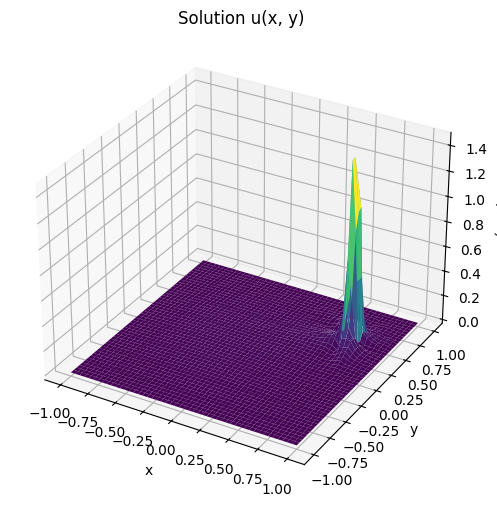

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 將 FEniCS 的解 u 轉換成 numpy 格式，準備畫圖
nx, ny = 50, 50
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
X, Y = np.meshgrid(x, y)

u_D_func = interpolate(u_D, V)

# 建立一個平面上的解的值 u(x, y)
Z = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        Z[i, j] = abs(u(x[i], y[j]) - u_D_func(x[i], y[j]))

# 畫 3D surface plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x, y)')
ax.set_title('Solution u(x, y)')
plt.show()